# 03 - Predictive Modelling

**MRP: Machine Learning-Based Auto Insurance Fraud Detection**
Meshwa Patel (501390663)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("car_insurance_clean.csv", parse_dates=["incident_date"])
print("Loaded:", df.shape)

Loaded: (30000, 25)


## 1. Feature engineering

I add a small number of features that the EDA suggested are useful, and that
match real-world fraud "red flags":
- **claim_to_premium** - how big the claim is relative to the premium paid
- **total_to_claim_ratio** - relationship between total and individual claim
- **no_witness_flag** - claim had zero witnesses (harder to verify)
- **no_police_report_flag** - no police report filed
- **authority_none_flag** - no emergency authority contacted
- **severity_score** - Minor(1) < Major(2) < Total Loss(3) as a number
- time features from the incident date: **month, weekday, hour**

In [2]:
df["claim_to_premium"] = df["claim_amount"] / df["policy_annual_premium"]
df["total_to_claim_ratio"] = df["total_claim_amount"] / (df["claim_amount"] + 1)
df["no_witness_flag"] = (df["witnesses"] == 0).astype(int)
df["no_police_report_flag"] = (df["police_report_available"] == "No").astype(int)
df["authority_none_flag"] = (df["authorities_contacted"] == "None").astype(int)

severity_map = {"Minor Damage": 1, "Major Damage": 2, "Total Loss": 3}
df["severity_score"] = df["incident_severity"].map(severity_map)

df["incident_month"] = df["incident_date"].dt.month
df["incident_weekday"] = df["incident_date"].dt.weekday
# (incident_hour_of_the_day already exists)

print("New engineered columns added. Data shape now:", df.shape)
df[["claim_to_premium", "total_to_claim_ratio", "no_witness_flag",
    "no_police_report_flag", "authority_none_flag", "severity_score"]].head()

New engineered columns added. Data shape now: (30000, 33)


,claim_to_premium,total_to_claim_ratio,no_witness_flag,no_police_report_flag,authority_none_flag,severity_score
0,5.704133,1.430665,1,0,0,3
1,21.722653,0.971180,0,1,0,3
2,8.606416,0.966465,0,1,0,3
3,21.189743,1.076909,0,1,0,3
4,14.994610,1.099386,0,1,0,1


## 2. Choose features and target

I drop identifier-type columns (`policy_id`, `incident_city`) and the raw date
and target columns. Everything else becomes a model feature.

In [3]:
target = "fraud"
drop_cols = ["policy_id", "incident_city", "incident_date", "fraud_reported",
             "fraud"]

X = df.drop(columns=drop_cols)
y = df[target]

# Split features into numeric vs categorical (for the preprocessing step)
categorical = X.select_dtypes(include="object").columns.tolist()
numeric = X.select_dtypes(exclude="object").columns.tolist()

print("Number of features:", X.shape[1])
print("\nCategorical features ({}):".format(len(categorical)), categorical)
print("\nNumeric features ({}):".format(len(numeric)), numeric)

Number of features: 28

Categorical features (11): ['policy_state', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'police_report_available']

Numeric features (17): ['policy_deductible', 'policy_annual_premium', 'insured_age', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'claim_amount', 'total_claim_amount', 'claim_to_premium', 'total_to_claim_ratio', 'no_witness_flag', 'no_police_report_flag', 'authority_none_flag', 'severity_score', 'incident_month', 'incident_weekday']


C:\Users\meshw\AppData\Local\Temp\ipykernel_31540\1736999182.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = X.select_dtypes(include="object").columns.tolist()


## 3. Train / Validation / Test split (70 / 15 / 15)

I use stratified splits so the fraud rate stays the same (~11.5%) in every
part. The test set is only touched at the very end.

In [4]:
# First split off 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
# Then split the 30% into 15% validation + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "fraud rate {:.1f}%".format(100 * y_train.mean()))
print("Valid:", X_val.shape, "fraud rate {:.1f}%".format(100 * y_val.mean()))
print("Test :", X_test.shape, "fraud rate {:.1f}%".format(100 * y_test.mean()))

Train: (21000, 28) fraud rate 11.5%
Valid: (4500, 28) fraud rate 11.5%
Test : (4500, 28) fraud rate 11.5%


## 4. Preprocessing



In [5]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                             eval_metric="logloss", random_state=RANDOM_STATE,
                             n_jobs=-1, tree_method="hist"),
    # hidden_layer_sizes=(32, 16) means 2 hidden layers: 32 nodes, then 16 nodes
    "Neural Network": MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                                    solver="adam", max_iter=300,
                                    early_stopping=True, random_state=RANDOM_STATE),
}

## 5. Train all 8 models and evaluate on the validation set

For each model I train one version **without SMOTE** and one **with SMOTE**,
then measure Precision, Recall, F1 (for the fraud class) and AUC-ROC.

In [6]:
def evaluate(pipe, X_eval, y_eval):
    """Return a dict of metrics for a fitted pipeline on given data."""
    pred = pipe.predict(X_eval)
    proba = pipe.predict_proba(X_eval)[:, 1]
    return {
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_eval, proba),
    }


results = []
fitted = {}   # keep the fitted pipelines so I can reuse the best one

for name, clf in models.items():
    for use_smote in [False, True]:
        if use_smote:
            pipe = ImbPipeline(steps=[
                ("prep", preprocessor),
                ("smote", SMOTE(random_state=RANDOM_STATE)),
                ("clf", clf),
            ])
        else:
            pipe = ImbPipeline(steps=[
                ("prep", preprocessor),
                ("clf", clf),
            ])
        pipe.fit(X_train, y_train)
        m = evaluate(pipe, X_val, y_val)
        tag = "SMOTE" if use_smote else "Original"
        m.update({"Model": name, "Data": tag})
        results.append(m)
        fitted[(name, tag)] = pipe
        print(f"{name:20s} | {tag:8s} | "
              f"P={m['Precision']:.3f} R={m['Recall']:.3f} "
              f"F1={m['F1']:.3f} AUC={m['AUC-ROC']:.3f}")

Logistic Regression  | Original | P=0.364 R=0.016 F1=0.030 AUC=0.698
Logistic Regression  | SMOTE    | P=0.207 R=0.612 F1=0.310 AUC=0.695
Random Forest        | Original | P=0.333 R=0.004 F1=0.008 AUC=0.740
Random Forest        | SMOTE    | P=0.434 R=0.045 F1=0.081 AUC=0.736
XGBoost              | Original | P=0.440 R=0.099 F1=0.161 AUC=0.731
XGBoost              | SMOTE    | P=0.431 R=0.103 F1=0.166 AUC=0.731
Neural Network       | Original | P=0.000 R=0.000 F1=0.000 AUC=0.603
Neural Network       | SMOTE    | P=0.218 R=0.357 F1=0.271 AUC=0.654


### The 8-row comparison table (proposal deliverable)

In [7]:
table = pd.DataFrame(results)[["Model", "Data", "Precision", "Recall", "F1", "AUC-ROC"]]
table = table.round(3)
table

,Model,Data,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,Original,0.364,0.016,0.030,0.698
1,Logistic Regression,SMOTE,0.207,0.612,0.310,0.695
2,Random Forest,Original,0.333,0.004,0.008,0.740
3,Random Forest,SMOTE,0.434,0.045,0.081,0.736
4,XGBoost,Original,0.440,0.099,0.161,0.731
5,XGBoost,SMOTE,0.431,0.103,0.166,0.731
6,Neural Network,Original,0.000,0.000,0.000,0.603
7,Neural Network,SMOTE,0.218,0.357,0.271,0.654


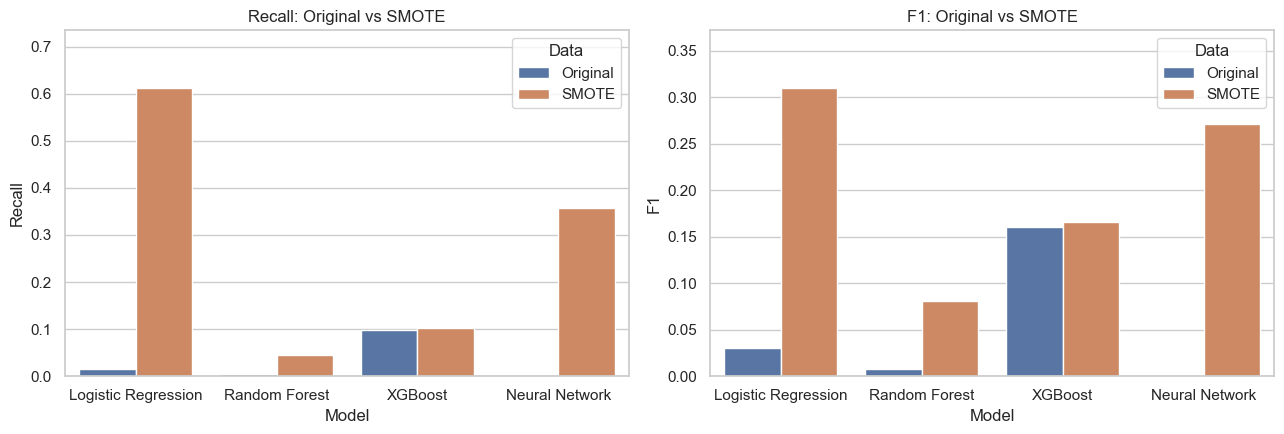

In [8]:
# Visualise the SMOTE effect on Recall and F1
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ["Recall", "F1"]):
    sns.barplot(data=table, x="Model", y=metric, hue="Data", ax=ax)
    ax.set_title(f"{metric}: Original vs SMOTE")
    ax.set_ylim(0, max(0.05, table[metric].max() * 1.2))
plt.tight_layout()
plt.savefig("12_smote_effect.png", dpi=110, bbox_inches="tight")
plt.show()

## 6. Pick the best model and test it

I pick the model+setting with the best **F1** on the validation set (F1
balances catching fraud with not crying wolf), then report its performance on
the untouched **test** set.

In [9]:
best_row = table.loc[table["F1"].idxmax()]
best_key = (best_row["Model"], best_row["Data"])
best_pipe = fitted[best_key]
print("Best model by validation F1:", best_key)

# Test-set performance
test_metrics = evaluate(best_pipe, X_test, y_test)
print("\nTest-set performance of the best model:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.3f}")

print("\nClassification report (test set):")
print(classification_report(y_test, best_pipe.predict(X_test),
                            target_names=["Not Fraud", "Fraud"], zero_division=0))

Best model by validation F1: ('Logistic Regression', 'SMOTE')

Test-set performance of the best model:
  Precision: 0.222
  Recall: 0.686
  F1: 0.335
  AUC-ROC: 0.726

Classification report (test set):
              precision    recall  f1-score   support

   Not Fraud       0.94      0.69      0.80      3984
       Fraud       0.22      0.69      0.34       516

    accuracy                           0.69      4500
   macro avg       0.58      0.69      0.57      4500
weighted avg       0.86      0.69      0.74      4500



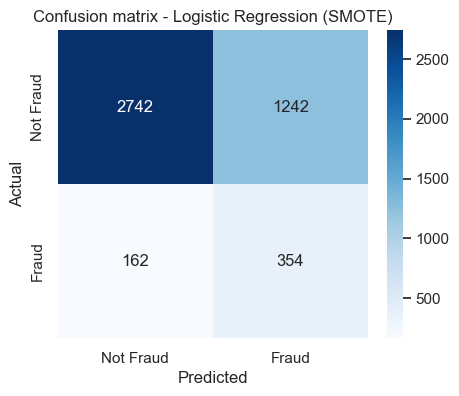

In [10]:
# Confusion matrix on the test set
cm = confusion_matrix(y_test, best_pipe.predict(X_test))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.title(f"Confusion matrix - {best_key[0]} ({best_key[1]})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("13_confusion_matrix.png", dpi=110, bbox_inches="tight")
plt.show()

### Confusion matrix for every model (test set)

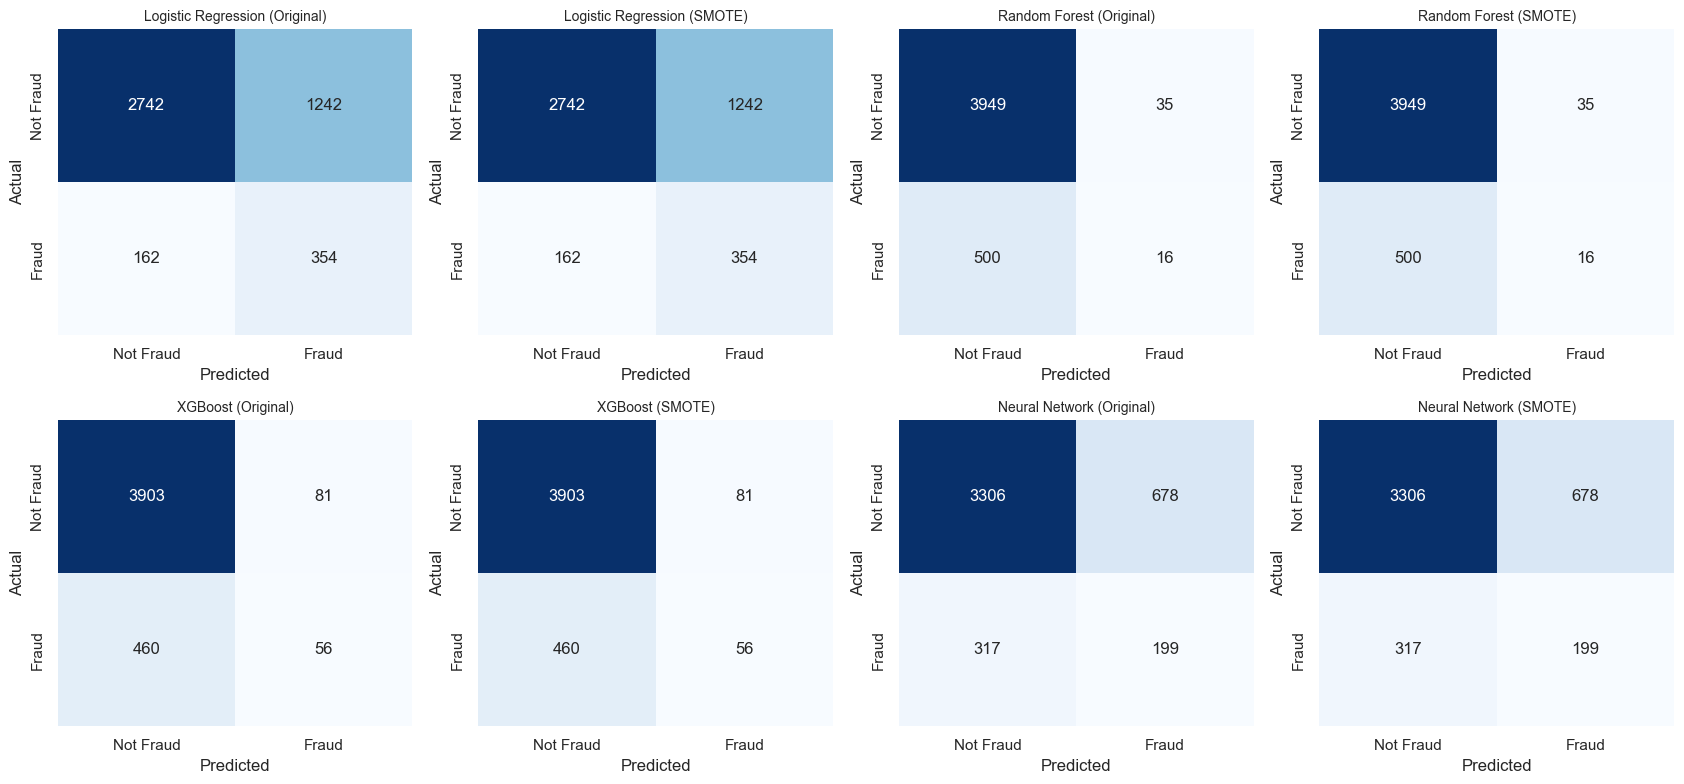

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, (key, pipe) in zip(axes.ravel(), fitted.items()):
    cm_i = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm_i, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Not Fraud", "Fraud"],
                yticklabels=["Not Fraud", "Fraud"], ax=ax)
    ax.set_title("{} ({})".format(key[0], key[1]), fontsize=10)
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("13b_confusion_all_models.png", dpi=110, bbox_inches="tight")
plt.show()

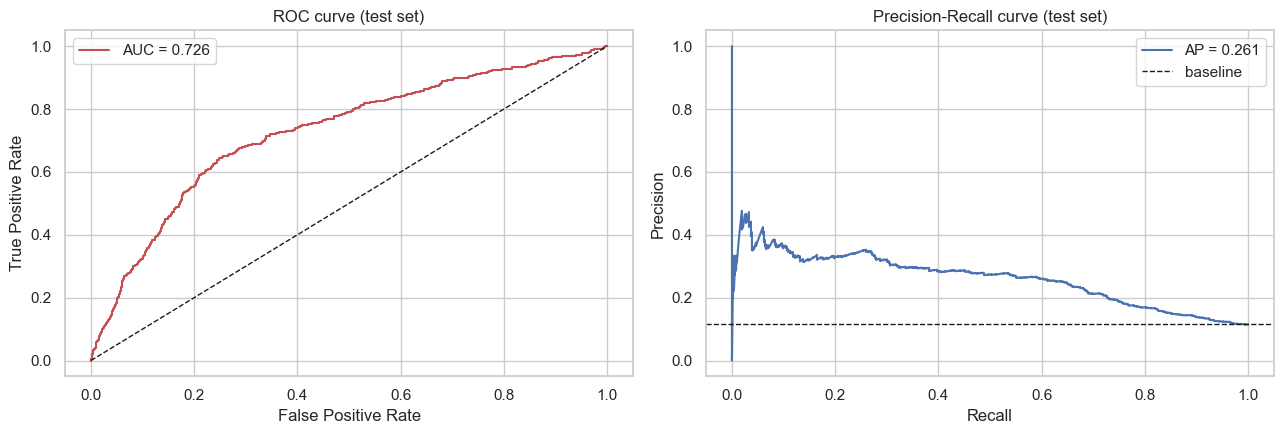

In [12]:
# ROC curve and Precision-Recall curve on the test set
proba_test = best_pipe.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fpr, tpr, label=f"AUC = {test_metrics['AUC-ROC']:.3f}", color="#C44E52")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC curve (test set)")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(rec, prec, label=f"AP = {ap:.3f}", color="#4C72B0")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label="baseline")
axes[1].set_title("Precision-Recall curve (test set)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.savefig("14_roc_pr_curves.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Explainability with SHAP

In [13]:
import shap

# Re-fit the preprocessing + classifier outside the pipeline so I can get the
# transformed matrix and the feature names for SHAP.
prep_fitted = best_pipe.named_steps["prep"]
feature_names = prep_fitted.get_feature_names_out()

X_train_t = prep_fitted.transform(X_train)
X_test_t = prep_fitted.transform(X_test)

# If SMOTE was in the best pipeline, resample the training matrix the same way
if "smote" in best_pipe.named_steps:
    X_train_t, y_train_res = best_pipe.named_steps["smote"].fit_resample(X_train_t, y_train)
else:
    y_train_res = y_train

# Train a fresh copy of the best classifier on the transformed data
best_clf_name = best_key[0]
shap_model = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                             eval_metric="logloss", random_state=RANDOM_STATE,
                             n_jobs=-1, tree_method="hist"),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                                    solver="adam", max_iter=300,
                                    early_stopping=True, random_state=RANDOM_STATE),
}[best_clf_name]

# Densify if needed (one-hot output is sparse)
import scipy.sparse as sp
if sp.issparse(X_train_t):
    X_train_t = X_train_t.toarray()
    X_test_t = X_test_t.toarray()

shap_model.fit(X_train_t, y_train_res)

# Sample of the test set for SHAP
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_test_t.shape[0], size=min(500, X_test_t.shape[0]), replace=False)
X_shap = X_test_t[sample_idx]

if best_clf_name in ["Random Forest", "XGBoost"]:
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_shap)
    # Random Forest returns a list [class0, class1]; take the fraud class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    # Newer SHAP can return (n, features, classes)
    if hasattr(shap_values, "ndim") and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]
elif best_clf_name == "Neural Network":
    # A neural network is not a tree and not linear, so I cannot use
    # TreeExplainer or LinearExplainer. KernelExplainer works for any model,
    # but it is slow, so I give it a small background sample and a small
    # number of claims to explain.
    background = shap.kmeans(X_train_t, 30)
    explainer = shap.KernelExplainer(
        lambda d: shap_model.predict_proba(d)[:, 1], background)
    X_shap = X_shap[:100]          # keep it small so it finishes quickly
    shap_values = explainer.shap_values(X_shap, nsamples=100)
else:
    explainer = shap.LinearExplainer(shap_model, X_train_t)
    shap_values = explainer.shap_values(X_shap)

print("SHAP values computed for", X_shap.shape[0], "claims.")

SHAP values computed for 500 claims.


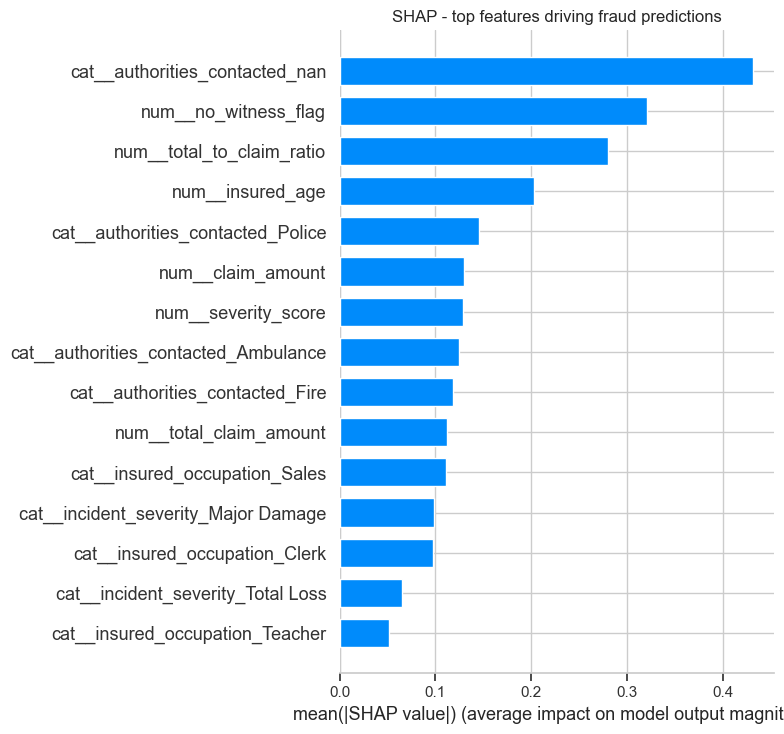

In [14]:
# Global feature importance: which features matter most overall
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("SHAP - top features driving fraud predictions")
plt.tight_layout()
plt.savefig("15_shap_importance.png", dpi=110, bbox_inches="tight")
plt.show()

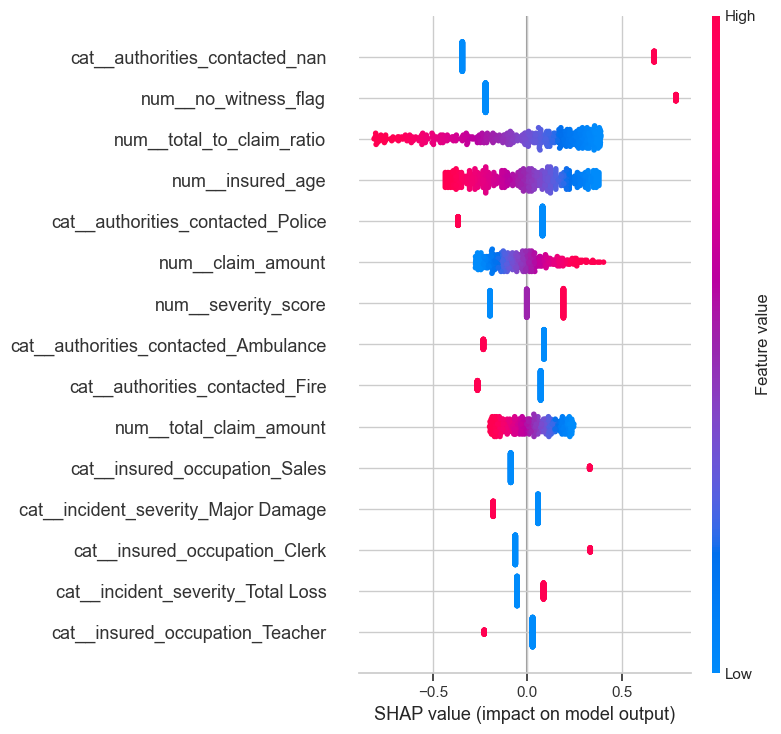

In [15]:
# Beeswarm: direction of each feature's effect
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  max_display=15, show=False)
plt.tight_layout()
plt.savefig("16_shap_beeswarm.png", dpi=110, bbox_inches="tight")
plt.show()

### Individual (local) SHAP explanations for representative claims

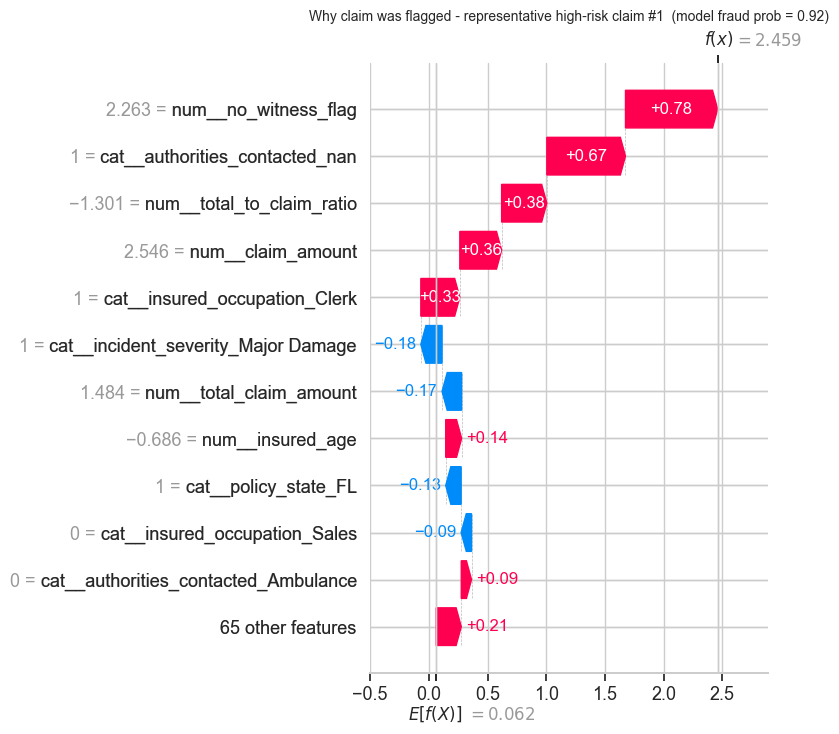

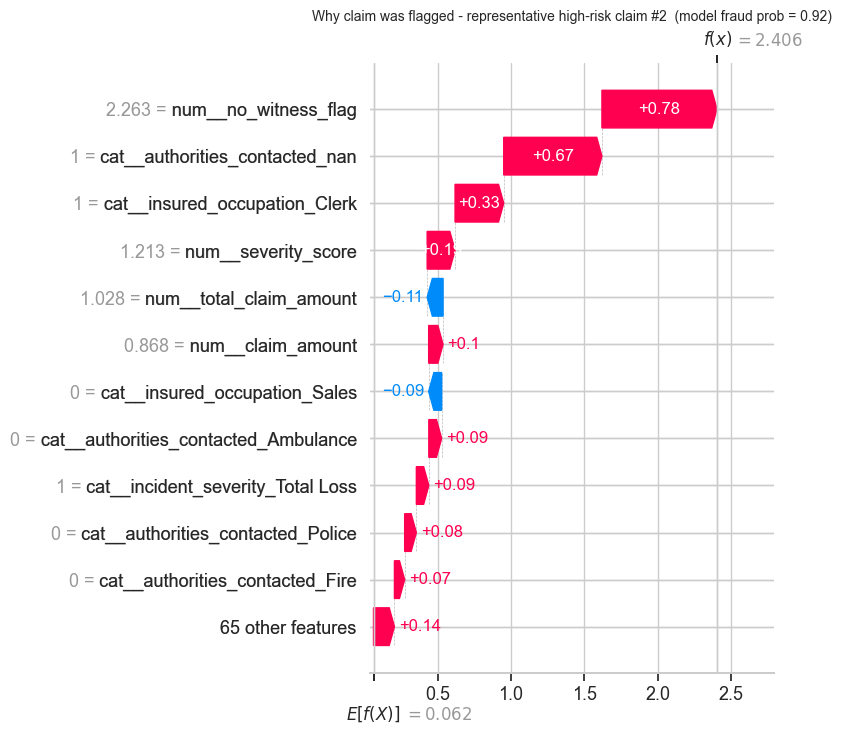

In [16]:
# Rank the sampled claims by predicted fraud probability and pick the top ones
sample_proba = shap_model.predict_proba(X_shap)[:, 1] if hasattr(shap_model, "predict_proba") else None
if sample_proba is None:
    order = np.argsort(-np.abs(shap_values).sum(axis=1))
else:
    order = np.argsort(-sample_proba)

# base value (expected model output) for the waterfall
try:
    base_val = explainer.expected_value
    if hasattr(base_val, "__len__"):
        base_val = base_val[1] if len(base_val) > 1 else base_val[0]
except Exception:
    base_val = float(np.mean(shap_values))

for rank, idx in enumerate(order[:2], start=1):
    expl = shap.Explanation(
        values=shap_values[idx],
        base_values=base_val,
        data=X_shap[idx],
        feature_names=feature_names,
    )
    plt.figure()
    shap.plots.waterfall(expl, max_display=12, show=False)
    ttl = "Why claim was flagged - representative high-risk claim #{}".format(rank)
    if sample_proba is not None:
        ttl += "  (model fraud prob = {:.2f})".format(sample_proba[idx])
    plt.title(ttl, fontsize=10)
    plt.tight_layout()
    plt.savefig("{}_shap_waterfall_claim{}.png".format(20 + rank, rank),
                dpi=110, bbox_inches="tight")
    plt.show()

## 8. Fraud Risk Scoring system (rule-based, data-driven points)

### Step 1 - measure each red flag on the training data

In [17]:
train_df = X_train.copy()
train_df["fraud"] = y_train.values

base_rate = train_df["fraud"].mean()
claim_cutoff = train_df["total_claim_amount"].quantile(0.90)   # from training only

print("Base fraud rate in training data: {:.2f}%".format(base_rate * 100))


def get_flags(data):
    """The red flags I want to test. Returns name -> True/False column."""
    return {
        "Total Loss severity":     data["incident_severity"] == "Total Loss",
        "No witnesses":            data["witnesses"] == 0,
        "Claim in top 10% amount": data["total_claim_amount"] > claim_cutoff,
        "Occupation Sales/Clerk":  data["insured_occupation"].isin(["Sales", "Clerk"]),
        "Claimant under 30":       data["insured_age"] < 30,
        "No police report":        data["police_report_available"] == "No",
        "No authority contacted":  data["authorities_contacted"] == "None",
    }


flag_rows = []
for name, mask in get_flags(train_df).items():
    fraud_rate = train_df.loc[mask, "fraud"].mean()
    lift = fraud_rate / base_rate
    flag_rows.append({"Flag": name,
                      "Claims with flag": int(mask.sum()),
                      "Fraud rate %": round(fraud_rate * 100, 2),
                      "Lift": round(lift, 2),
                      "Keep?": "yes" if lift >= 1.10 else "no - too weak"})

flag_table = pd.DataFrame(flag_rows).sort_values("Lift", ascending=False)
print("\nHow strong is each red flag?")
flag_table

Base fraud rate in training data: 11.47%

How strong is each red flag?


,Flag,Claims with flag,Fraud rate %,Lift,Keep?
1,No witnesses,3431,20.37,1.78,yes
4,Claimant under 30,4338,15.38,1.34,yes
0,Total Loss severity,7107,15.06,1.31,yes
3,Occupation Sales/Clerk,5214,14.67,1.28,yes
5,No police report,10546,11.59,1.01,no - too weak
2,Claim in top 10% amount,2100,10.71,0.93,no - too weak
6,No authority contacted,0,NaN,NaN,no - too weak


### Step 2 - turn the lift into points

In [18]:
kept = flag_table[flag_table["Keep?"] == "yes"].copy()

# excess lift = how much ABOVE the base rate this flag pushes fraud
kept["excess"] = kept["Lift"] - 1

# scale so the strongest flag is worth 30 points
kept["Points"] = (kept["excess"] / kept["excess"].max() * 30).round(0).astype(int)

points = dict(zip(kept["Flag"], kept["Points"]))

print("New points, based on the data instead of my guesses:")
for flag, pts in sorted(points.items(), key=lambda kv: -kv[1]):
    print("   {:<26s} {:>3d} points".format(flag, pts))
print("\nMaximum possible score:", sum(points.values()))

New points, based on the data instead of my guesses:
   No witnesses                30 points
   Claimant under 30           13 points
   Total Loss severity         12 points
   Occupation Sales/Clerk      11 points

Maximum possible score: 66


### Step 3 - calculate the score and set the tier cut-points

In [19]:
def risk_score(data):
    """Add up the points for every claim."""
    score = pd.Series(0, index=data.index)
    for name, mask in get_flags(data).items():
        if name in points:                      # only the flags that survived
            score = score + mask.astype(int) * points[name]
    return score


# cut-points come from the TRAINING data so the test set stays untouched
train_scores = risk_score(train_df)
cut_low = train_scores.quantile(0.45)
cut_high = train_scores.quantile(0.85)

print("Tier cut-points (from training data):")
print("   Low    : score <= {:.0f}".format(cut_low))
print("   Medium : score <= {:.0f}".format(cut_high))
print("   High   : score >  {:.0f}".format(cut_high))


def risk_tier(score):
    return pd.cut(score, bins=[-1, cut_low, cut_high, 999],
                  labels=["Low", "Medium", "High"])

Tier cut-points (from training data):
   Low    : score <= 12
   Medium : score <= 30
   High   : score >  30


### Step 4 - does it actually work? (checked on the held-out test set)


In [20]:
test_df = X_test.copy()
test_df["fraud"] = y_test.values
test_df["risk_score"] = risk_score(test_df)
test_df["risk_tier"] = risk_tier(test_df["risk_score"])

tier_summary = test_df.groupby("risk_tier")["fraud"].agg(
    **{"Number of claims": "count", "Actual fraud rate": "mean"})
tier_summary["Actual fraud rate"] = (tier_summary["Actual fraud rate"] * 100).round(2)

print("RISK TIERS ON THE TEST SET")
print(tier_summary)

low = tier_summary.loc["Low", "Actual fraud rate"]
high = tier_summary.loc["High", "Actual fraud rate"]
print("\nThe High tier has {:.1f}x the fraud rate of the Low tier.".format(high / low))

RISK TIERS ON THE TEST SET
           Number of claims  Actual fraud rate
risk_tier                                     
Low                    2719               8.79
Medium                 1256              10.91
High                    525              26.67

The High tier has 3.0x the fraud rate of the Low tier.


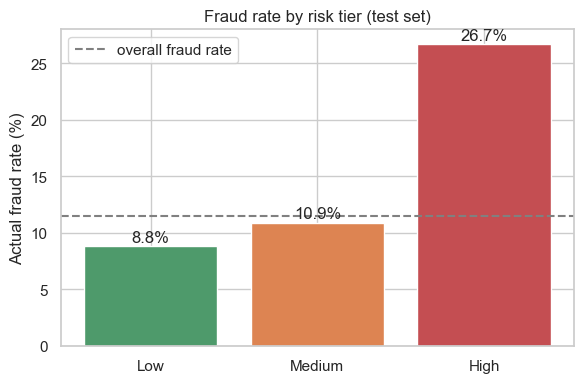

In [21]:
plt.figure(figsize=(6, 4))
colours = {"Low": "#4E9A6B", "Medium": "#DD8452", "High": "#C44E52"}
plt.bar(tier_summary.index.astype(str), tier_summary["Actual fraud rate"],
        color=[colours[t] for t in tier_summary.index.astype(str)])
plt.axhline(y_test.mean() * 100, ls="--", color="grey", label="overall fraud rate")
for i, v in enumerate(tier_summary["Actual fraud rate"]):
    plt.text(i, v + 0.4, "{:.1f}%".format(v), ha="center")
plt.ylabel("Actual fraud rate (%)")
plt.title("Fraud rate by risk tier (test set)")
plt.legend()
plt.tight_layout()
plt.savefig("17_risk_tiers.png", dpi=110, bbox_inches="tight")
plt.show()

### Does the simple score agree with the machine learning model?

In [22]:
model_proba = best_pipe.predict_proba(X_test)[:, 1]
agreement = np.corrcoef(test_df["risk_score"], model_proba)[0, 1]
print("Correlation between the rule-based score and the model: {:.3f}".format(agreement))
print("(They were built in completely different ways, so strong agreement is")
print(" reassuring - two independent methods pointing at the same claims.)")

Correlation between the rule-based score and the model: 0.576
(They were built in completely different ways, so strong agreement is
 reassuring - two independent methods pointing at the same claims.)


## 9. Bias / fairness check across demographic groups


In [23]:
# Build a small dataframe of test-set predictions with demographics attached
test_dem = df.loc[X_test.index, ["insured_sex", "insured_age",
                                 "insured_education_level"]].copy()
test_dem["actual"] = y_test.values
test_dem["pred"] = best_pipe.predict(X_test)
test_dem["age_band"] = pd.cut(test_dem["insured_age"],
                              bins=[0, 30, 45, 60, 200],
                              labels=["<30", "30-44", "45-59", "60+"])


def group_fairness(frame, col):
    rows = []
    for g, sub in frame.groupby(col, observed=True):
        n = len(sub)
        actual_rate = sub["actual"].mean()
        flag_rate = sub["pred"].mean()
        # recall = caught frauds / real frauds in this group
        real_fraud = sub[sub["actual"] == 1]
        recall = (real_fraud["pred"] == 1).mean() if len(real_fraud) else np.nan
        rows.append({col: str(g), "n": n,
                     "actual_fraud_%": round(100 * actual_rate, 1),
                     "flag_rate_%": round(100 * flag_rate, 1),
                     "recall_%": round(100 * recall, 1) if recall == recall else None})
    return pd.DataFrame(rows)


for col in ["insured_sex", "age_band", "insured_education_level"]:
    print("\n=== Fairness by {} (test set) ===".format(col))
    print(group_fairness(test_dem, col).to_string(index=False))


=== Fairness by insured_sex (test set) ===
insured_sex    n  actual_fraud_%  flag_rate_%  recall_%
     FEMALE 1496            11.2         33.4      72.5
       MALE 1495            12.0         36.3      65.9
      OTHER 1509            11.3         36.7      67.6

=== Fairness by age_band (test set) ===
age_band    n  actual_fraud_%  flag_rate_%  recall_%
     <30 1015            13.6         47.3      71.0
   30-44 1126            11.4         38.4      70.3
   45-59 1184             9.8         31.3      68.1
     60+ 1175            11.4         26.6      64.9

=== Fairness by insured_education_level (test set) ===
insured_education_level    n  actual_fraud_%  flag_rate_%  recall_%
                College 1159            10.9         35.8      76.2
            High School 1157            11.9         33.9      67.4
                Masters 1072            11.4         35.3      62.3
                    PhD 1112            11.7         37.0      68.5


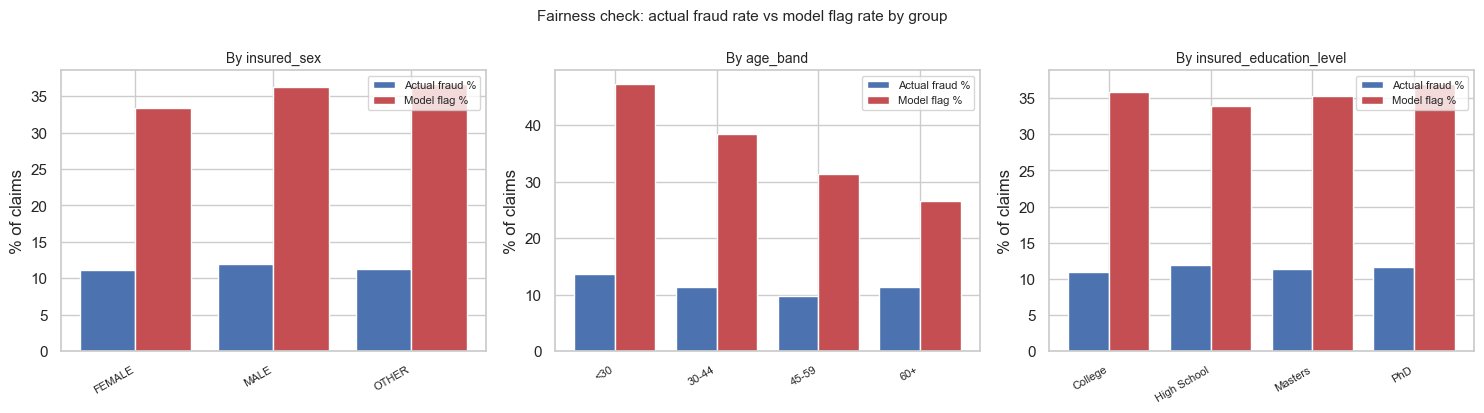

In [24]:
# Visualise: actual fraud rate vs model flag rate per group (they should track)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col in zip(axes, ["insured_sex", "age_band", "insured_education_level"]):
    gf = group_fairness(test_dem, col)
    xpos = np.arange(len(gf))
    ax.bar(xpos - 0.2, gf["actual_fraud_%"], width=0.4, label="Actual fraud %", color="#4C72B0")
    ax.bar(xpos + 0.2, gf["flag_rate_%"], width=0.4, label="Model flag %", color="#C44E52")
    ax.set_xticks(xpos); ax.set_xticklabels(gf[col], rotation=30, ha="right", fontsize=8)
    ax.set_title("By {}".format(col), fontsize=10)
    ax.set_ylabel("% of claims")
    ax.legend(fontsize=8)
plt.suptitle("Fairness check: actual fraud rate vs model flag rate by group", fontsize=11)
plt.tight_layout()
plt.savefig("23_fairness_by_group.png", dpi=110, bbox_inches="tight")
plt.show()

### Can I actually fix this bias?

In [25]:
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score

def age_band(a):
    return pd.cut(a, bins=[0, 30, 45, 60, 200],
                  labels=["<30", "30-44", "45-59", "60+"])

# --- Option 1: retrain without demographic features ---
demographic_cols = ["insured_age", "insured_sex", "insured_education_level"]
X_train_fair = X_train.drop(columns=demographic_cols)
X_test_fair = X_test.drop(columns=demographic_cols)

cat_fair = X_train_fair.select_dtypes(include="object").columns.tolist()
num_fair = X_train_fair.select_dtypes(exclude="object").columns.tolist()

prep_fair = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_fair),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_fair),
])

fair_model = ImbPipeline(steps=[
    ("prep", prep_fair),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
fair_model.fit(X_train_fair, y_train)

fair_pred = fair_model.predict(X_test_fair)
fair_proba = fair_model.predict_proba(X_test_fair)[:, 1]

base_pred = best_pipe.predict(X_test)

print("PERFORMANCE COST OF REMOVING DEMOGRAPHICS")
print("  original model : F1 {:.3f} | recall {:.3f} | AUC {:.3f}".format(
    f1_score(y_test, base_pred), recall_score(y_test, base_pred),
    roc_auc_score(y_test, best_pipe.predict_proba(X_test)[:, 1])))
print("  without demogs : F1 {:.3f} | recall {:.3f} | AUC {:.3f}".format(
    f1_score(y_test, fair_pred), recall_score(y_test, fair_pred),
    roc_auc_score(y_test, fair_proba)))

C:\Users\meshw\AppData\Local\Temp\ipykernel_31540\3430580721.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_fair = X_train_fair.select_dtypes(include="object").columns.tolist()


PERFORMANCE COST OF REMOVING DEMOGRAPHICS
  original model : F1 0.335 | recall 0.686 | AUC 0.726
  without demogs : F1 0.338 | recall 0.684 | AUC 0.723


In [26]:
# compare how often each age group gets flagged, before and after
compare = X_test.copy()
compare["actual"] = y_test.values
compare["flag_before"] = base_pred
compare["flag_after"] = fair_pred
compare["age_band"] = age_band(compare["insured_age"])

summary = compare.groupby("age_band").agg(
    actual_fraud=("actual", "mean"),
    flagged_before=("flag_before", "mean"),
    flagged_after=("flag_after", "mean"))
summary = (summary * 100).round(1)
summary["gap_before"] = (summary["flagged_before"] - summary["actual_fraud"]).round(1)
summary["gap_after"] = (summary["flagged_after"] - summary["actual_fraud"]).round(1)

print("FLAG RATE BY AGE GROUP (%)")
print(summary)
print("\n'gap' is how much more often a group is flagged than it actually offends.")
print("A big spread in the gap column means the model treats groups unequally.")

FLAG RATE BY AGE GROUP (%)
          actual_fraud  flagged_before  flagged_after  gap_before  gap_after
age_band                                                                    
<30               13.6            47.3           35.4        33.7       21.8
30-44             11.4            38.4           35.3        27.0       23.9
45-59              9.8            31.3           34.4        21.5       24.6
60+               11.4            26.6           35.0        15.2       23.6

'gap' is how much more often a group is flagged than it actually offends.
A big spread in the gap column means the model treats groups unequally.


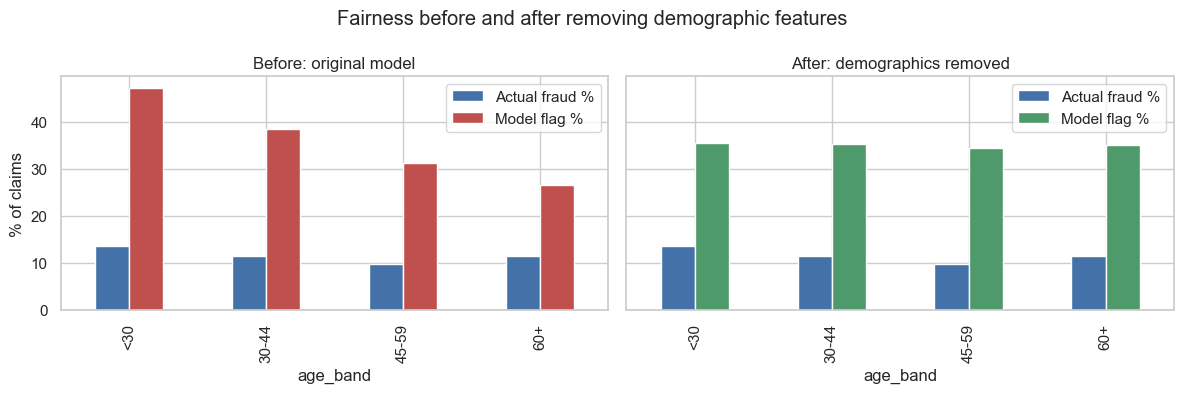

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

summary[["actual_fraud", "flagged_before"]].plot(kind="bar", ax=axes[0],
                                                 color=["#4472A8", "#C0504D"])
axes[0].set_title("Before: original model")
axes[0].set_ylabel("% of claims")
axes[0].legend(["Actual fraud %", "Model flag %"])

summary[["actual_fraud", "flagged_after"]].plot(kind="bar", ax=axes[1],
                                                color=["#4472A8", "#4E9A6B"])
axes[1].set_title("After: demographics removed")
axes[1].legend(["Actual fraud %", "Model flag %"])

plt.suptitle("Fairness before and after removing demographic features")
plt.tight_layout()
plt.savefig("23b_fairness_mitigation.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Cross-validation check (how stable are these results?)

In [28]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
import scipy.stats as st

# 5 folds, repeated 2 times = 10 scores for every model
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

# the scores I want to record
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

print("Cross-validation setup: 5 folds x 2 repeats = 10 scores per model")
print("Note: the next cell trains 8 models x 10 folds = 80 fits, so it takes a few minutes.")

Cross-validation setup: 5 folds x 2 repeats = 10 scores per model
Note: the next cell trains 8 models x 10 folds = 80 fits, so it takes a few minutes.


### Run cross-validation on all 8 configurations

In [29]:
def run_cv(pipe, name, data_type):
    """Run cross-validation on one pipeline and summarise the scores."""
    cv_scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    row = {"Model": name, "Data": data_type}

    for metric in ["accuracy", "f1", "roc_auc"]:
        scores = cv_scores["test_" + metric]
        n = len(scores)
        mean = scores.mean()
        sd = scores.std(ddof=1)

        # 95% confidence interval for the mean.
        # If every fold gave the exact same score then sd is 0 and there is no
        # interval to work out, so I just use the mean itself.
        if sd == 0:
            low, high = mean, mean
        else:
            low, high = st.t.interval(0.95, n - 1, loc=mean, scale=sd / np.sqrt(n))

        # store everything as percentages, in separate columns
        row[metric + " Mean %"] = round(mean * 100, 2)
        row[metric + " Std %"] = round(sd * 100, 2)
        row[metric + " CI Low %"] = round(low * 100, 2)
        row[metric + " CI High %"] = round(high * 100, 2)

    return row


cv_results = []

for name, clf in models.items():
    for use_smote in [False, True]:
        if use_smote:
            pipe = ImbPipeline(steps=[
                ("prep", preprocessor),
                ("smote", SMOTE(random_state=RANDOM_STATE)),
                ("clf", clf),
            ])
        else:
            pipe = ImbPipeline(steps=[
                ("prep", preprocessor),
                ("clf", clf),
            ])

        tag = "SMOTE" if use_smote else "Original"
        cv_results.append(run_cv(pipe, name, tag))
        print("done:", name, "-", tag)

cv_table = pd.DataFrame(cv_results)
print("\nCross-validation finished.")

done: Logistic Regression - Original
done: Logistic Regression - SMOTE
done: Random Forest - Original
done: Random Forest - SMOTE
done: XGBoost - Original
done: XGBoost - SMOTE
done: Neural Network - Original
done: Neural Network - SMOTE

Cross-validation finished.


### Accuracy results


In [30]:
accuracy_table = cv_table[["Model", "Data",
                           "accuracy Mean %", "accuracy Std %",
                           "accuracy CI Low %", "accuracy CI High %"]]
print("ACCURACY (%)")
accuracy_table

ACCURACY (%)


,Model,Data,accuracy Mean %,accuracy Std %,accuracy CI Low %,accuracy CI High %
0,Logistic Regression,Original,88.41,0.09,88.35,88.48
1,Logistic Regression,SMOTE,69.28,0.46,68.96,69.61
2,Random Forest,Original,88.50,0.06,88.46,88.54
3,Random Forest,SMOTE,88.22,0.16,88.11,88.33
4,XGBoost,Original,87.90,0.17,87.78,88.02
5,XGBoost,SMOTE,87.90,0.21,87.75,88.05
6,Neural Network,Original,88.50,0.10,88.43,88.57
7,Neural Network,SMOTE,79.65,0.91,79.00,80.31


In [31]:
# What would a lazy model score if it simply said "nothing is fraud"?
baseline_accuracy = (1 - y.mean()) * 100
print("Baseline accuracy if the model always predicts 'not fraud': {:.2f} %".format(
    baseline_accuracy))
print("\nCompare this with the 'Original' rows in the table above.")

Baseline accuracy if the model always predicts 'not fraud': 88.53 %

Compare this with the 'Original' rows in the table above.


### F1 results

F1 is the measure I actually selected my best model on, because it balances
catching fraud (recall) against false alarms (precision).

In [32]:
f1_table = cv_table[["Model", "Data",
                     "f1 Mean %", "f1 Std %",
                     "f1 CI Low %", "f1 CI High %"]].sort_values("f1 Mean %",
                                                                ascending=False)
print("F1-SCORE (%)")
f1_table

F1-SCORE (%)


,Model,Data,f1 Mean %,f1 Std %,f1 CI Low %,f1 CI High %
1,Logistic Regression,SMOTE,32.58,0.63,32.13,33.03
7,Neural Network,SMOTE,30.31,0.68,29.82,30.80
5,XGBoost,SMOTE,18.03,1.17,17.20,18.87
4,XGBoost,Original,17.35,1.90,15.99,18.72
3,Random Forest,SMOTE,7.92,1.16,7.09,8.75
0,Logistic Regression,Original,2.96,0.53,2.58,3.33
6,Neural Network,Original,1.18,3.63,-1.42,3.78
2,Random Forest,Original,1.17,0.54,0.78,1.56


### AUC-ROC results

In [33]:
auc_table = cv_table[["Model", "Data",
                      "roc_auc Mean %", "roc_auc Std %",
                      "roc_auc CI Low %", "roc_auc CI High %"]].sort_values(
                          "roc_auc Mean %", ascending=False)
print("AUC-ROC (%)")
auc_table

AUC-ROC (%)


,Model,Data,roc_auc Mean %,roc_auc Std %,roc_auc CI Low %,roc_auc CI High %
2,Random Forest,Original,75.50,0.54,75.11,75.88
4,XGBoost,Original,75.17,0.64,74.71,75.63
3,Random Forest,SMOTE,75.14,0.70,74.64,75.64
5,XGBoost,SMOTE,75.13,0.90,74.48,75.77
0,Logistic Regression,Original,71.32,0.60,70.89,71.75
1,Logistic Regression,SMOTE,71.21,0.56,70.81,71.61
7,Neural Network,SMOTE,67.30,0.63,66.85,67.75
6,Neural Network,Original,64.55,3.15,62.30,66.80


### F1 with error bars

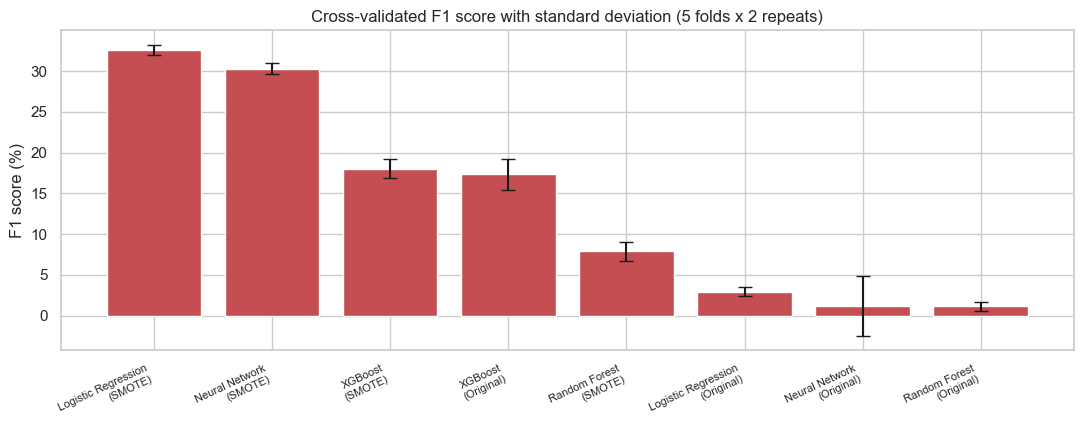

In [34]:
plot_data = cv_table.copy()
plot_data["Label"] = plot_data["Model"] + "\n(" + plot_data["Data"] + ")"
plot_data = plot_data.sort_values("f1 Mean %", ascending=False)

plt.figure(figsize=(11, 4.5))
plt.bar(plot_data["Label"], plot_data["f1 Mean %"],
        yerr=plot_data["f1 Std %"], capsize=5, color="#C44E52")
plt.ylabel("F1 score (%)")
plt.title("Cross-validated F1 score with standard deviation (5 folds x 2 repeats)")
plt.xticks(rotation=25, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("24_cv_f1_errorbars.png", dpi=110, bbox_inches="tight")
plt.show()

## 11. Error analysis

In [35]:
errors = X_test.copy()
errors["actual"] = y_test.values
errors["pred"] = best_pipe.predict(X_test)
errors["proba"] = best_pipe.predict_proba(X_test)[:, 1]

missed = errors[(errors["actual"] == 1) & (errors["pred"] == 0)]   # false negatives
caught = errors[(errors["actual"] == 1) & (errors["pred"] == 1)]   # true positives
false_alarms = errors[(errors["actual"] == 0) & (errors["pred"] == 1)]

print("Frauds missed      :", len(missed))
print("Frauds caught      :", len(caught))
print("False alarms raised:", len(false_alarms))

Frauds missed      : 162
Frauds caught      : 354
False alarms raised: 1242


In [36]:
print("RED FLAGS: how many of these claims carried each warning sign?\n")
print("%-26s %10s %10s" % ("Red flag", "missed", "caught"))
for c in ["no_witness_flag", "no_police_report_flag", "authority_none_flag"]:
    print("%-26s %9.1f%% %9.1f%%" % (c, missed[c].mean()*100, caught[c].mean()*100))

print("\nAVERAGE VALUES\n")
print("%-26s %10s %10s" % ("feature", "missed", "caught"))
for c in ["witnesses", "severity_score", "insured_age", "total_claim_amount"]:
    print("%-26s %10.2f %10.2f" % (c, missed[c].mean(), caught[c].mean()))

print("\nINCIDENT SEVERITY (% of claims)\n")
sev = pd.DataFrame({
    "missed": missed["incident_severity"].value_counts(normalize=True) * 100,
    "caught": caught["incident_severity"].value_counts(normalize=True) * 100}).round(1)
print(sev)

RED FLAGS: how many of these claims carried each warning sign?

Red flag                       missed     caught
no_witness_flag                 12.3%      40.7%
no_police_report_flag           47.5%      54.0%
authority_none_flag              0.0%       0.0%

AVERAGE VALUES

feature                        missed     caught
witnesses                        2.67       1.74
severity_score                   1.98       2.25
insured_age                     46.91      44.75
total_claim_amount           12967.75   12846.50

INCIDENT SEVERITY (% of claims)

                   missed  caught
incident_severity                
Major Damage         33.3    27.1
Minor Damage         34.6    23.7
Total Loss           32.1    49.2


In [37]:
print("HOW CLOSE WERE THE MISSED FRAUDS?\n")
print("average predicted probability: {:.3f}".format(missed["proba"].mean()))
print("highest predicted probability: {:.3f}".format(missed["proba"].max()))
near_miss = (missed["proba"] >= 0.40).sum()
print("\nmissed frauds scoring between 0.40 and 0.50 (just under the cut-off): "
      "{} of {} ({:.0f}%)".format(near_miss, len(missed), near_miss/len(missed)*100))

HOW CLOSE WERE THE MISSED FRAUDS?

average predicted probability: 0.327
highest predicted probability: 0.499

missed frauds scoring between 0.40 and 0.50 (just under the cut-off): 42 of 162 (26%)


## 12. Was 0.5 the right cut-off?


In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for t in np.arange(0.30, 0.76, 0.05):
    pred_t = (errors["proba"] >= t).astype(int)
    rows.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(y_test, pred_t, zero_division=0), 3),
        "Recall": round(recall_score(y_test, pred_t), 3),
        "F1": round(f1_score(y_test, pred_t), 3),
        "Claims flagged": int(pred_t.sum()),
        "Frauds caught": int(((pred_t == 1) & (y_test == 1)).sum()),
    })

threshold_table = pd.DataFrame(rows)
print("THRESHOLD SWEEP (test set)")
threshold_table

THRESHOLD SWEEP (test set)


,Threshold,Precision,Recall,F1,Claims flagged,Frauds caught
0,0.30,0.144,0.878,0.247,3148,453
1,0.35,0.159,0.826,0.266,2684,426
2,0.40,0.177,0.767,0.288,2235,396
3,0.45,0.198,0.731,0.312,1903,377
4,0.50,0.222,0.686,0.335,1596,354
5,0.55,0.251,0.640,0.360,1317,330
6,0.60,0.270,0.548,0.362,1047,283
7,0.65,0.285,0.444,0.347,803,229
8,0.70,0.295,0.326,0.310,569,168
9,0.75,0.342,0.238,0.281,360,123


In [39]:
# Choosing a threshold properly means tuning it on VALIDATION, not on test.
val_proba = best_pipe.predict_proba(X_val)[:, 1]

best_t, best_f1 = 0.5, 0
for t in np.arange(0.30, 0.76, 0.01):
    f = f1_score(y_val, (val_proba >= t).astype(int))
    if f > best_f1:
        best_f1, best_t = f, t

tuned_pred = (errors["proba"] >= best_t).astype(int)
default_pred = (errors["proba"] >= 0.5).astype(int)

print("Best threshold found on the validation set: {:.2f}".format(best_t))
print("\n  tuned  -> test F1 {:.3f} | recall {:.3f} | flagged {}".format(
    f1_score(y_test, tuned_pred), recall_score(y_test, tuned_pred), tuned_pred.sum()))
print("  default 0.50 -> test F1 {:.3f} | recall {:.3f} | flagged {}".format(
    f1_score(y_test, default_pred), recall_score(y_test, default_pred), default_pred.sum()))

Best threshold found on the validation set: 0.60

  tuned  -> test F1 0.362 | recall 0.548 | flagged 1047
  default 0.50 -> test F1 0.335 | recall 0.686 | flagged 1596


In [40]:
# In practice an insurer would pick the threshold using costs, not F1.
print("COST-BASED VIEW")
print("If missing a fraud costs C times as much as a wasted investigation:\n")
print("%4s %12s %10s %14s" % ("C", "best cut-off", "recall", "claims flagged"))
for C in [3, 5, 10, 20]:
    best_thr, best_cost = 0.5, 1e18
    for t in np.arange(0.05, 0.96, 0.01):
        p = (errors["proba"] >= t).astype(int)
        fn = ((p == 0) & (y_test == 1)).sum()
        fp = ((p == 1) & (y_test == 0)).sum()
        cost = C * fn + fp
        if cost < best_cost:
            best_cost, best_thr = cost, t
    p = (errors["proba"] >= best_thr).astype(int)
    print("%4d %12.2f %10.3f %14d" % (C, best_thr, recall_score(y_test, p), p.sum()))

COST-BASED VIEW
If missing a fraud costs C times as much as a wasted investigation:

   C best cut-off     recall claims flagged
   3         0.74      0.264            392
   5         0.58      0.589           1147
  10         0.52      0.671           1479
  20         0.29      0.893           3245


## 13. Would tuning the models have changed anything?


In [41]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

tune_pipe = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                          n_jobs=-1, tree_method="hist")),
])

param_grid = {
    "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.05, 0.1],
    "clf__n_estimators": [200, 400],
}

search = GridSearchCV(tune_pipe, param_grid, scoring="roc_auc",
                      cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                      n_jobs=-1)
search.fit(X_train, y_train)

print("Best settings found:", search.best_params_)
print("Best cross-validated AUC: {:.4f}".format(search.best_score_))

tuned_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
print("\nTuned XGBoost on the test set: AUC {:.4f}".format(roc_auc_score(y_test, tuned_proba)))
print("Untuned XGBoost was around 0.73, and my best model (Logistic Regression")
print("+ SMOTE) reached 0.726.")

Best settings found: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 400}
Best cross-validated AUC: 0.7563

Tuned XGBoost on the test set: AUC 0.7695
Untuned XGBoost was around 0.73, and my best model (Logistic Regression
+ SMOTE) reached 0.726.


## 14. Advanced analysis (going deeper than the basic results)

 Training size Fraction  Test AUC
          2100      10%    0.6880
          5250      25%    0.7140
         10500      50%    0.7222
         15750      75%    0.7256
         21000     100%    0.7264


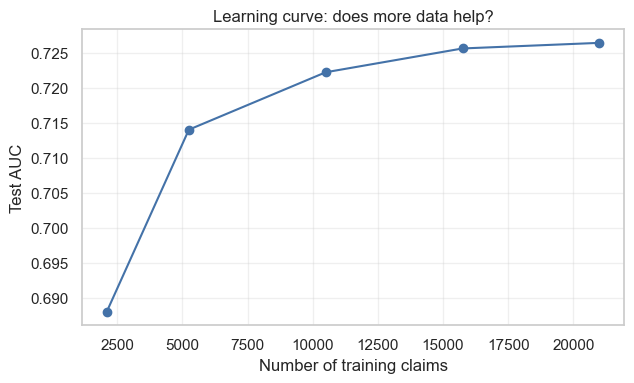

In [42]:
from sklearn.metrics import roc_auc_score

learning_rows = []
for frac in [0.1, 0.25, 0.5, 0.75, 1.0]:
    n = int(len(X_train) * frac)
    part_model = ImbPipeline(steps=[
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    part_model.fit(X_train.iloc[:n], y_train.iloc[:n])
    auc = roc_auc_score(y_test, part_model.predict_proba(X_test)[:, 1])
    learning_rows.append({"Training size": n, "Fraction": f"{int(frac*100)}%",
                          "Test AUC": round(auc, 4)})

learning_table = pd.DataFrame(learning_rows)
print(learning_table.to_string(index=False))

plt.figure(figsize=(6.5, 4))
plt.plot(learning_table["Training size"], learning_table["Test AUC"],
         marker="o", color="#4472A8")
plt.xlabel("Number of training claims")
plt.ylabel("Test AUC")
plt.title("Learning curve: does more data help?")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("31_learning_curve.png", dpi=110, bbox_inches="tight")
plt.show()

### 14.2 Precision@K - how good is the model as a ranking tool?


In [43]:
test_proba = best_pipe.predict_proba(X_test)[:, 1]
ranking = np.argsort(-test_proba)          # most risky first
y_arr = y_test.values
total_fraud = y_arr.sum()

k_rows = []
for k in [50, 100, 250, 500, 1000]:
    top_k = ranking[:k]
    found = int(y_arr[top_k].sum())
    k_rows.append({"Claims reviewed (K)": k,
                   "Frauds found": found,
                   "Precision @K": f"{found/k*100:.1f}%",
                   "% of all fraud caught": f"{found/total_fraud*100:.1f}%"})

precision_at_k = pd.DataFrame(k_rows)
print(precision_at_k.to_string(index=False))
print("\nFor comparison, reviewing random claims would find only {:.1f}% fraud.".format(
    y_arr.mean() * 100))

 Claims reviewed (K)  Frauds found Precision @K % of all fraud caught
                  50            20        40.0%                  3.9%
                 100            36        36.0%                  7.0%
                 250            82        32.8%                 15.9%
                 500           157        31.4%                 30.4%
                1000           276        27.6%                 53.5%

For comparison, reviewing random claims would find only 11.5% fraud.


### 14.3 Feature ablation - which features actually carry the signal?


In [44]:
feature_groups = {
    "All features (baseline)": [],
    "Remove engineered": ["claim_to_premium", "total_to_claim_ratio", "no_witness_flag",
                          "no_police_report_flag", "authority_none_flag", "severity_score"],
    "Remove incident severity": ["incident_severity", "severity_score"],
    "Remove witness info": ["witnesses", "no_witness_flag"],
    "Remove authority info": ["authorities_contacted", "authority_none_flag"],
    "Remove demographics": ["insured_age", "insured_sex", "insured_education_level"],
    "Remove money features": ["claim_amount", "total_claim_amount",
                             "claim_to_premium", "total_to_claim_ratio"],
}

ablation_rows = []
baseline_auc = None
for label, drop in feature_groups.items():
    drop = [c for c in drop if c in X_train.columns]
    Xa, Xb = X_train.drop(columns=drop), X_test.drop(columns=drop)
    ca = Xa.select_dtypes(include="object").columns.tolist()
    na = Xa.select_dtypes(exclude="object").columns.tolist()
    pipe = ImbPipeline(steps=[
        ("prep", ColumnTransformer([("num", StandardScaler(), na),
                                    ("cat", OneHotEncoder(handle_unknown="ignore"), ca)])),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pipe.fit(Xa, y_train)
    auc = roc_auc_score(y_test, pipe.predict_proba(Xb)[:, 1])
    if baseline_auc is None:
        baseline_auc = auc
        change = 0.0
    else:
        change = auc - baseline_auc
    ablation_rows.append({"Setup": label, "Test AUC": round(auc, 4),
                          "Change vs baseline": round(change, 4)})

ablation_table = pd.DataFrame(ablation_rows)
print(ablation_table.to_string(index=False))

C:\Users\meshw\AppData\Local\Temp\ipykernel_31540\665124706.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ca = Xa.select_dtypes(include="object").columns.tolist()
C:\Users\meshw\AppData\Local\Temp\ipykernel_31540\665124706.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

                   Setup  Test AUC  Change vs baseline
 All features (baseline)    0.7264              0.0000
       Remove engineered    0.7120             -0.0144
Remove incident severity    0.7165             -0.0099
     Remove witness info    0.6961             -0.0303
   Remove authority info    0.6561             -0.0703
     Remove demographics    0.7229             -0.0035
   Remove money features    0.7052             -0.0212


### 14.4 Statistical significance - is the model difference real?


In [45]:
# McNemar's test checks whether two models make mistakes on the SAME claims or
# different ones. I compute it directly from its formula so I do not need an
# extra library (statsmodels), which may not be installed everywhere.

# train an XGBoost to compare against
xgb_compare = ImbPipeline(steps=[
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                          eval_metric="logloss", random_state=RANDOM_STATE,
                          n_jobs=-1, tree_method="hist")),
]).fit(X_train, y_train)
xgb_proba = xgb_compare.predict_proba(X_test)[:, 1]

# bootstrap the AUC difference
rng = np.random.default_rng(RANDOM_STATE)
diffs = []
for _ in range(2000):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    if y_arr[idx].sum() == 0:
        continue
    d = roc_auc_score(y_arr[idx], xgb_proba[idx]) - roc_auc_score(y_arr[idx], test_proba[idx])
    diffs.append(d)
diffs = np.array(diffs)
lo, hi = np.percentile(diffs, [2.5, 97.5])

print("Logistic Regression AUC : {:.4f}".format(roc_auc_score(y_test, test_proba)))
print("XGBoost AUC             : {:.4f}".format(roc_auc_score(y_test, xgb_proba)))
print("Average AUC difference  : {:.4f}".format(diffs.mean()))
print("95% confidence interval : [{:.4f}, {:.4f}]".format(lo, hi))
verdict = "REAL difference (interval does not include 0)" if (lo > 0 or hi < 0) else "could be noise"
print("Verdict                 :", verdict)

# McNemar test, computed directly.
# b = model A right, model B wrong ; c = model A wrong, model B right
pa = (test_proba >= 0.5).astype(int)
pb = (xgb_proba >= 0.5).astype(int)
b = int(((pa == y_arr) & (pb != y_arr)).sum())
c = int(((pa != y_arr) & (pb == y_arr)).sum())
mcnemar_stat = (abs(b - c) - 1) ** 2 / (b + c)   # with continuity correction
# p-value from the chi-square (1 df) survival function
from scipy.stats import chi2
mcnemar_p = chi2.sf(mcnemar_stat, df=1)
print("\nMcNemar test: statistic = {:.1f}, p-value = {:.3g}".format(mcnemar_stat, mcnemar_p))
print("(b = {} claims only LogReg got right, c = {} only XGBoost got right)".format(b, c))

Logistic Regression AUC : 0.7264
XGBoost AUC             : 0.7638
Average AUC difference  : 0.0374
95% confidence interval : [0.0180, 0.0563]
Verdict                 : REAL difference (interval does not include 0)

McNemar test: statistic = 502.4, p-value = 2.86e-111
(b = 308 claims only LogReg got right, c = 1171 only XGBoost got right)


### 14.5 Calibration - can I trust the probabilities?


Brier score (lower is better) : 0.2101
Brier if always guessing base rate : 0.1015

       mean_predicted  actual_rate
band                             
0              0.156        0.042
1              0.226        0.044
2              0.275        0.051
3              0.325        0.060
4              0.373        0.069
5              0.432        0.053
6              0.504        0.084
7              0.586        0.184
8              0.677        0.236
9              0.807        0.322


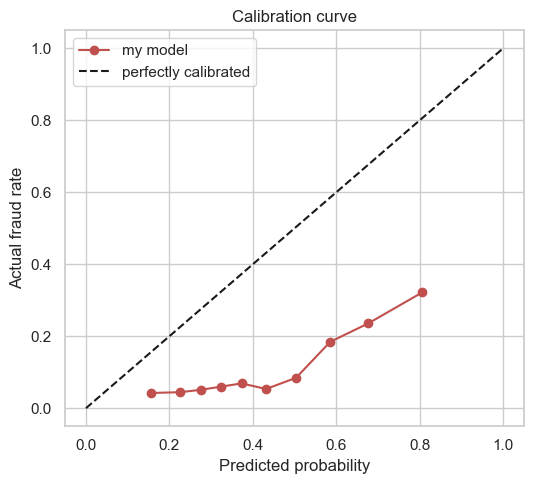

In [46]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, test_proba)
brier_base = brier_score_loss(y_test, np.full(len(y_test), y_test.mean()))
print("Brier score (lower is better) : {:.4f}".format(brier))
print("Brier if always guessing base rate : {:.4f}".format(brier_base))

bands = pd.qcut(test_proba, 10, labels=False, duplicates="drop")
calib = pd.DataFrame({"band": bands, "pred": test_proba, "actual": y_arr})
calib_summary = calib.groupby("band").agg(mean_predicted=("pred", "mean"),
                                          actual_rate=("actual", "mean"))
print("\n", (calib_summary * 1).round(3).to_string())

plt.figure(figsize=(5.5, 5))
plt.plot(calib_summary["mean_predicted"], calib_summary["actual_rate"],
         marker="o", color="#C0504D", label="my model")
plt.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
plt.xlabel("Predicted probability")
plt.ylabel("Actual fraud rate")
plt.title("Calibration curve")
plt.legend()
plt.tight_layout()
plt.savefig("32_calibration.png", dpi=110, bbox_inches="tight")
plt.show()

### 14.6 Business value - is the model actually worth using?


In [47]:
AVG_FRAUD_VALUE = 12900     # average total claim amount in the dataset

business_rows = []
for invest_cost in [200, 500]:
    for thr in [0.5, 0.6]:
        pred = (test_proba >= thr).astype(int)
        tp = int(((pred == 1) & (y_arr == 1)).sum())
        fp = int(((pred == 1) & (y_arr == 0)).sum())
        recovered = tp * AVG_FRAUD_VALUE
        spent = (tp + fp) * invest_cost
        business_rows.append({
            "Invest. cost/claim": f"${invest_cost}",
            "Threshold": thr,
            "Claims reviewed": int(pred.sum()),
            "Frauds caught": tp,
            "Recovered": f"${recovered:,}",
            "Cost": f"${spent:,}",
            "Net benefit": f"${recovered - spent:,}",
        })

business_table = pd.DataFrame(business_rows)
print(business_table.to_string(index=False))
print("\n(These figures are on the 4,500-claim test set only. Scaled to a real")
print(" insurer's volume the numbers would be far larger.)")

Invest. cost/claim  Threshold  Claims reviewed  Frauds caught  Recovered     Cost Net benefit
              $200        0.5             1596            354 $4,566,600 $319,200  $4,247,400
              $200        0.6             1047            283 $3,650,700 $209,400  $3,441,300
              $500        0.5             1596            354 $4,566,600 $798,000  $3,768,600
              $500        0.6             1047            283 $3,650,700 $523,500  $3,127,200

(These figures are on the 4,500-claim test set only. Scaled to a real
 insurer's volume the numbers would be far larger.)
